# Notebook for analysing the behaviour of Integrated Energy Hubs

In [2]:
import json
import os
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd

In [3]:
DATABASE_PATH = "../../database/eBuS.duckdb"
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}
SCENARIOS = ["summer", "winter", "reduced", "increased", "gridsoc"]
SEEDS = [65, 67, 68, 70, 75]
#OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
OUTPUT_PATH = Path(r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\FinalPlots")

## Total Energy Consumed, Charged and Generated


In [3]:
def total_energy_consumption():
    con = duckdb.connect(DATABASE_PATH)
    df = con.execute(
        """
        SELECT
            station_id,
            station_pvCurtailed,
            station_energyChargedStorage,
            station_gridEnergyDrawn,
            station_pvGenerated,
            scenario,
            seed
        FROM multirun_ess
        WHERE station_id NOT IN ('cd_cicerostrasse_01', 'cd_muellerstrasse_01')
        """
    ).fetchdf()

    con.close()

    energy_cols = ["station_pvCurtailed", "station_energyChargedStorage",
    "station_gridEnergyDrawn", "station_pvGenerated"]
    df[energy_cols] = df[energy_cols] / 1000

    for scenario in [
        "summer", 
        "winter", 
        ]:

        mean_instance_collection = {}
        std_instance_collection = {}
        count_instance_collection = {}

        for seed in SEEDS:

            subset = df[
                (df["scenario"] == scenario) &
                (df["seed"] == seed)
            ].copy()

            print("\n" + "=" * 70)
            print(f"IEHs statistics — {scenario.upper()} — Seed {seed}")
            print("=" * 70)



            print(subset.describe())

total_energy_consumption()


IEHs statistics — SUMMER — Seed 65
       station_pvCurtailed  station_energyChargedStorage  \
count         80040.000000                  80040.000000   
mean              0.037332                      0.050870   
std               0.401067                      0.303751   
min               0.000000                      0.000000   
25%               0.000000                      0.000000   
50%               0.000000                      0.000000   
75%               0.000000                      0.000000   
max               7.295350                      5.164668   

       station_gridEnergyDrawn  station_pvGenerated     seed  
count             80040.000000         80040.000000  80040.0  
mean                  1.573930             0.163955     65.0  
std                   2.596407             0.551554      0.0  
min                   0.000000             0.000000     65.0  
25%                   0.000000             0.000000     65.0  
50%                   0.833333             0.

In [ ]:
ENERGY_COLS = [
    "station_pvCurtailed",
    "station_energyChargedBus",
    "station_energyChargedStorage",
    "station_gridEnergyDrawn",
    "station_pvGenerated",
]


def total_energy_consumption_system():
    con = duckdb.connect(DATABASE_PATH)
    df = con.execute(
        """
        SELECT
            station_id,
            station_pvCurtailed,
            station_energyChargedBus,
            station_energyChargedStorage,
            station_gridEnergyDrawn,
            station_pvGenerated,
            scenario,
            seed
        FROM multirun_ess
        WHERE station_id NOT IN ('cd_cicerostrasse_01', 'cd_muellerstrasse_01')
        """
    ).fetchdf()
    con.close()

    df[ENERGY_COLS] = df[ENERGY_COLS] / 1000  # Wh -> kWh

    # One row per (scenario, seed): system total over all stations
    totals = (
        df[df["seed"].isin(SEEDS)]
        .groupby(["scenario", "seed"])[ENERGY_COLS]
        .sum()
    )

    for scenario in SCENARIOS:

        print("\n" + "#" * 80)
        print(f"SCENARIO: {scenario.upper()} — system totals over stations [kWh]")
        print("#" * 80)

        sc = totals.loc[scenario]

        # Per-seed totals
        print("\nPer-seed totals:")
        print(sc.to_string(float_format=lambda x: f"{x:,.2f}"))

        # Across-seed statistics
        n = len(sc)
        print("\n" + "-" * 80)
        print(f"Across-seed statistics (n = {n} seeds)")
        print("-" * 80)

        for col in ENERGY_COLS:
            v = sc[col]
            mean = v.mean()
            sd = v.std(ddof=0) 
            cv = sd / mean * 100 if mean != 0 else float("nan")


            print(f"\nMetric: {col}")
            print("-" * 40)
            print(f"Mean                  = {mean:,.4f}")
            print(f"SD (between seeds)    = {sd:,.4f}")
            print(f"Variance              = {sd ** 2:,.4f}")
            print(f"CV                    = {cv:.4f} %")
            print(f"Min / Max             = {v.min():,.4f} / {v.max():,.4f}")
            print(f"Range                 = {v.max() - v.min():,.4f}")

    return totals


totals = total_energy_consumption_system()


################################################################################
SCENARIO: SUMMER — system totals over stations [kWh]
################################################################################

Per-seed totals:
      station_pvCurtailed  station_energyChargedBus  station_energyChargedStorage  station_gridEnergyDrawn  station_pvGenerated
seed                                                                                                                           
65               2,988.07                132,133.28                      4,071.61               125,977.38            13,122.94
67               2,981.47                132,191.72                      4,073.86               126,032.76            13,122.94
68               2,980.40                132,145.69                      4,073.56               125,994.24            13,122.94
70               2,983.45                132,154.57                      4,073.86               125,998.48            13,122.9

In [ ]:
def _charging_events_energy(events, time_grid):
    """Distribute each event's energy evenly over its duration and
    return the resulting energy [kWh] per timestep, sampled at
    ``time_grid`` [h], matching the per-timestep energy convention of
    ``station_energyCharged``.
    """
    dt_h = time_grid[1] - time_grid[0]
    duration_h = events["end_time"] - events["start_time"]
    power_kw = (events["energy_charged_kwh"] / duration_h).to_numpy()

    start_idx = np.searchsorted(time_grid, events["start_time"].to_numpy())
    end_idx = np.searchsorted(time_grid, events["end_time"].to_numpy())

    delta = np.zeros(len(time_grid) + 1)
    np.add.at(delta, start_idx, power_kw)
    np.add.at(delta, end_idx, -power_kw)

    return np.cumsum(delta)[:len(time_grid)] * dt_h

def stacked_ieh_power_no_depot(output_dir=r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots"):

    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyChargedBus,
            scenario
        FROM multirun_ess
        WHERE seed = 65
        ORDER BY timestep_time
        """
    ).fetchdf()

    con.close()

    solution_path = (
        r"..\files\postprocessing_input\solution.json"
    )
    with open(solution_path, "r") as f:
        solution = json.load(f)

    events = pd.DataFrame(solution["charging_events"])
    events[["start_time", "end_time"]] = events[["start_time", "end_time"]] / 60

    for scenario in ["summer", "winter", "reduced", "increased", "nodepot", "mildwinter"]:

        subset = df[df["scenario"] == scenario].copy()
        subset["timestep_time"] = subset["timestep_time"] / 3600
        energy_cols = ["station_gridEnergyDrawn",
                        "station_pvCurtailed",
                        "station_pvGenerated",
                        "station_energyChargedBus"]
        subset[energy_cols] = subset[energy_cols] / 1000
        totals = subset.groupby("timestep_time")[
            ["station_gridEnergyDrawn", "station_pvCurtailed",
                "station_pvGenerated", "station_energyChargedBus"]
        ].sum().reset_index()
        fig, ax = plt.subplots(figsize=(12, 6))

        pv_stored = (
            totals["station_pvGenerated"]
            - totals["station_energyChargedBus"]
            - totals["station_pvCurtailed"]
        ).clip(lower=0)

        ax.stackplot(
            totals["timestep_time"],
            totals["station_gridEnergyDrawn"],
            pv_stored,
            totals["station_pvCurtailed"],
            alpha=0.7,
            step="mid",
            labels=[
                "Grid Energy Drawn",
                "PV Stored",
                "PV Curtailed",
            ],
            colors=["tab:red", "gold", "tab:purple"],
        )

        event_energy = _charging_events_energy(
            events, totals["timestep_time"].to_numpy()
        )

        ax.plot(
            totals["timestep_time"],
            totals["station_energyChargedBus"],
            color="black",
            linewidth=0.5,
            linestyle=":",
            label="Energy Charged",
        )

        ax.plot(
            totals["timestep_time"],
            event_energy,
            color="tab:blue",
            linewidth=1,
            linestyle="--",
            label="Charging Events (Solution)",
        )

        series = [
            ("Grid Energy Drawn", totals["station_gridEnergyDrawn"], "tab:red"),
            ("PV Stored", pv_stored, "gold"),
            ("PV Curtailed", totals["station_pvCurtailed"], "tab:purple"),
        ]

        cumulative = np.zeros(len(totals))
        for label, values, color in series:
            cumulative += values.to_numpy()
            peak_idx = values.idxmax()
            peak_x = totals["timestep_time"].loc[peak_idx]
            peak_y = cumulative[peak_idx]
            peak_val = values.loc[peak_idx]

            ax.scatter(peak_x, peak_y, color=color, edgecolor="black", zorder=5)
            ax.annotate(
                f"{peak_val:.0f}",
                (peak_x, peak_y),
                textcoords="offset points", xytext=(0, 6),
                fontsize=8, color=color, ha="center",
            )

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Energy [kWh]")
        ax.legend()

        fig.savefig(
            os.path.join(output_dir, f"{scenario}_ess_stacked_depot.pdf")
        )
        plt.tight_layout()
        print(scenario)
        plt.show()

stacked_ieh_power_no_depot()

In [ ]:
def solution_events_to_time_row(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data["charging_events"])
    df = df.sort_values(by="start_time").reset_index(drop=True)

    time_row = pd.DataFrame({
        "time": np.arange(1800),
        "energy_charged_kwh": 0.0
    })

    for _, event in df.iterrows():
        start = event["start_time"]
        end = event["end_time"]
        energy = event["energy_charged_kwh"]

        duration = end - start

        if duration <= 0:
            continue

        # Energy charged per minute during this event
        energy_per_minute = energy / duration

        # Only check timesteps that can overlap with this event
        first_timestep = max(0, int(np.floor(start)))
        last_timestep = min(1799, int(np.floor(end)))

        for timestep in range(first_timestep, last_timestep + 1):
            timestep_start = timestep
            timestep_end = timestep + 1

            # Calculate how many minutes of this timestep
            # overlap with the charging event
            overlap = max(
                0,
                min(end, timestep_end) -
                max(start, timestep_start)
            )

            time_row.loc[
                time_row["time"] == timestep,
                "energy_charged_kwh"
            ] += energy_per_minute * overlap
    time_row.to_csv("charging_energy_timerow.csv", index=False)
    return time_row

solution_events_to_time_row(r"G:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus\scenario\eBuS\files\postprocessing_input\solution.json")

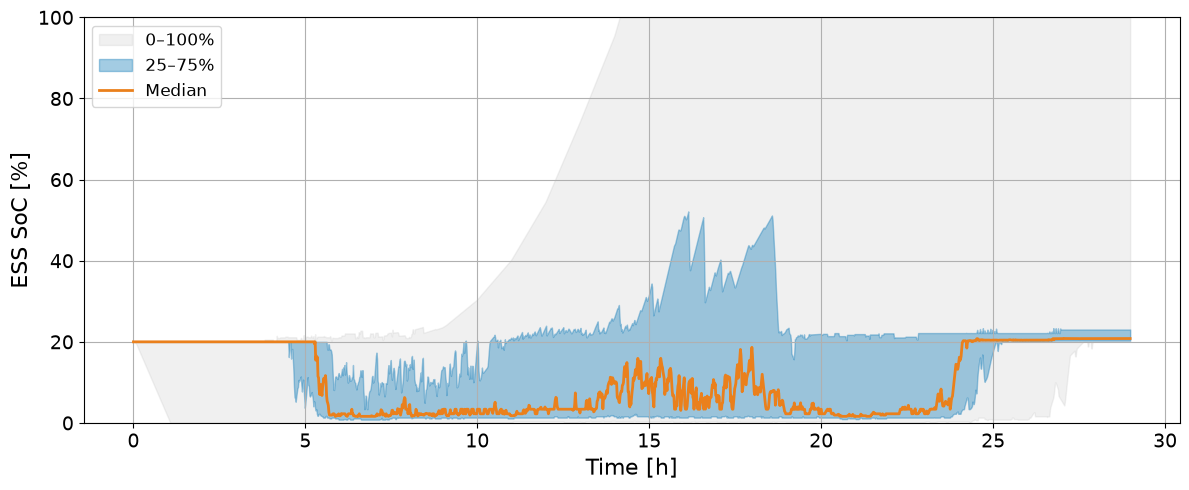

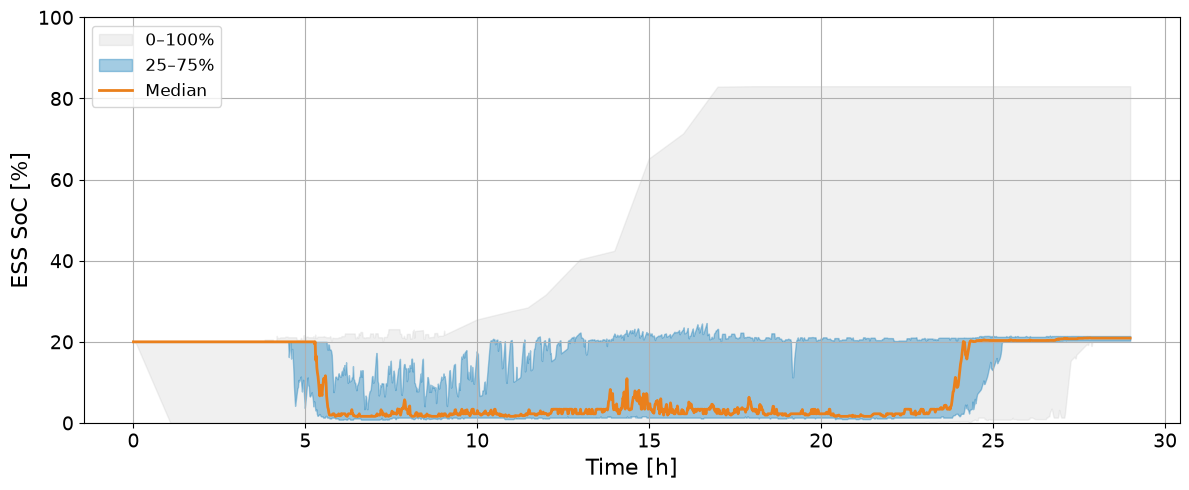

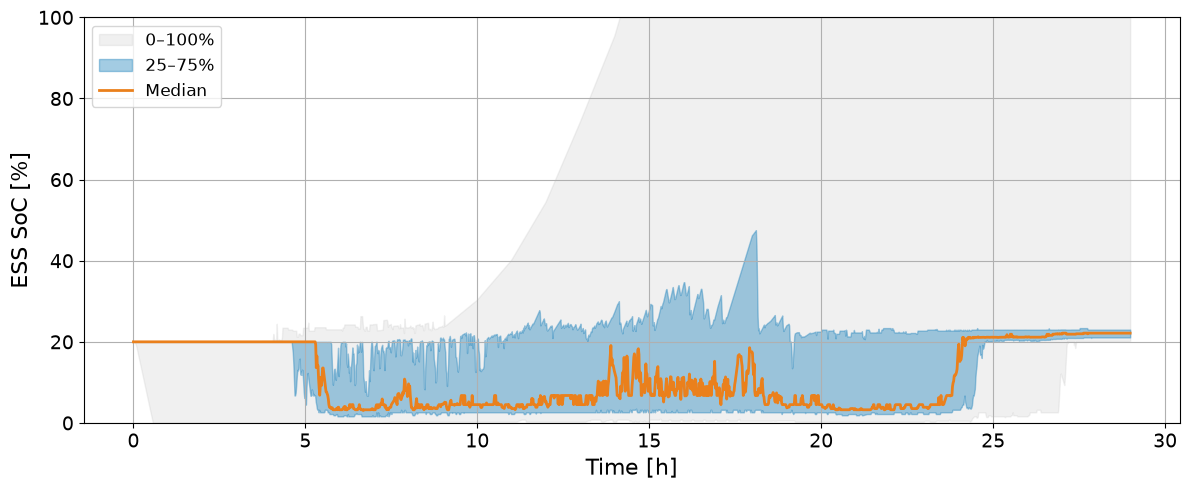

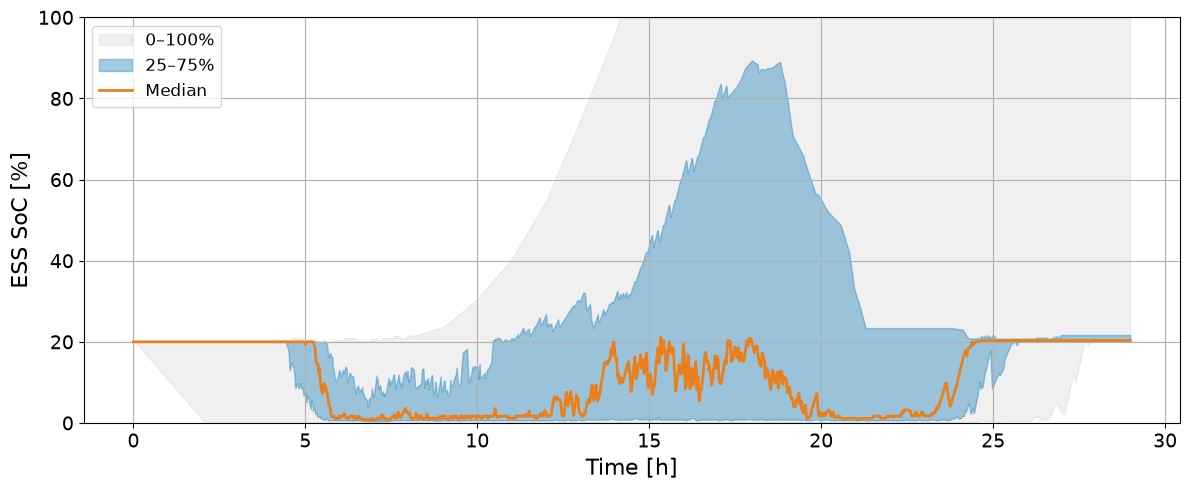

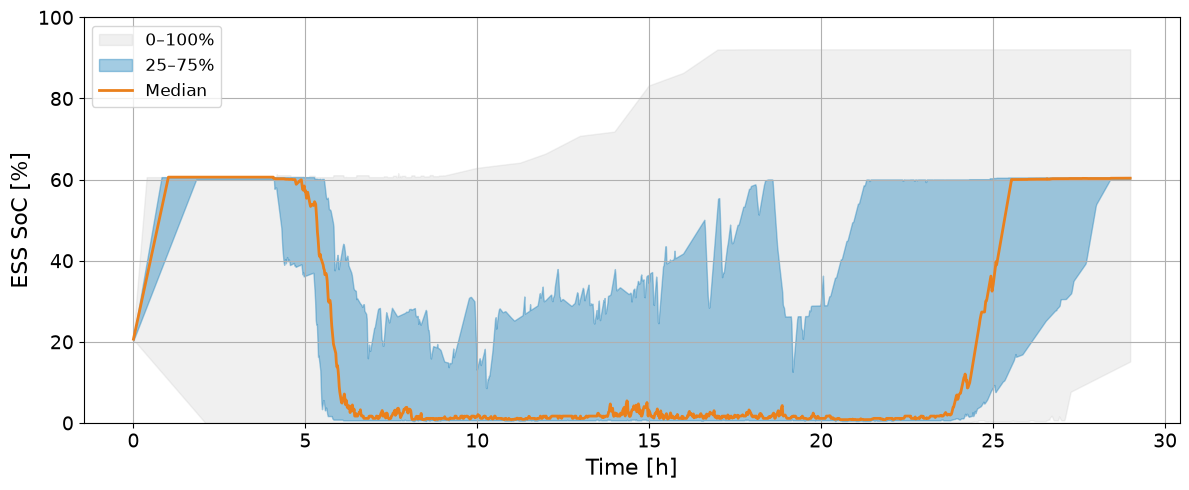

In [32]:
def ess_soc_over_time(output_dir: Path):

    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_essSoc,
            station_id,
            station_capacity,
            scenario,
            seed
        FROM multirun_ess
        WHERE seed = 65
        ORDER BY timestep_time
        """
    ).fetchdf()

    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_essSoc_pct"] = df["station_essSoc"] / df["station_capacity"] * 100

    for scenario in SCENARIOS:
        subset = df[df["scenario"] == scenario]

        # pivot: rows = time, cols = station
        pivot = subset.pivot_table(
            index="timestep_time", columns="station_id", values="station_essSoc_pct"
        ).sort_index()

        q = pivot.quantile([0.0, 0.25, 0.5, 0.75, 1.0], axis=1).T

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.fill_between(q.index, q[0.0], q[1.0], alpha=0.2, label="0–100%", color="#b8b8b8")
        ax.fill_between(q.index, q[0.25], q[0.75], alpha=0.4, label="25–75%", color="#1a80bb")
        ax.plot(q.index, q[0.5], lw=2, label="Median", color="#ea801c")
        ax.tick_params(labelsize=14)
        ax.set_xlabel("Time [h]", fontsize=16)
        ax.set_ylabel("ESS SoC [%]", fontsize=16)
        ax.set_ylim(0, 100)
        ax.grid(True)
        ax.legend(fontsize=12)
        plt.tight_layout()
        fig.savefig(output_dir / f"{scenario}_ess_over_time.pdf")
        plt.show()
        plt.close(fig)


ess_soc_over_time(OUTPUT_PATH)